In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.ticker as ticker
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk import FreqDist, ngrams
from collections import Counter
import re




[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tabeerasif/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tabeerasif/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tabeerasif/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
data = pd.read_csv('./dataset/dontpatronizeme_pcl.tsv', sep='\t', skiprows=4, header=None)
data.columns = ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']

# Preview the dataset
data.head()

,par_id,art_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


Paragraph Token Count Statistics:

count    10469.000000
mean        48.629095
std         29.173851
min          1.000000
25%         30.000000
50%         42.000000
75%         60.000000
max        910.000000
Name: token_count, dtype: float64


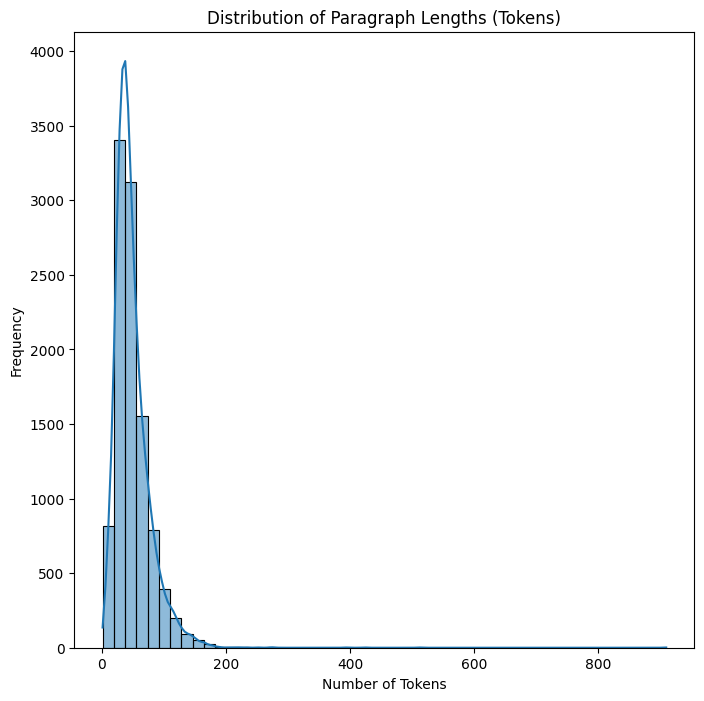

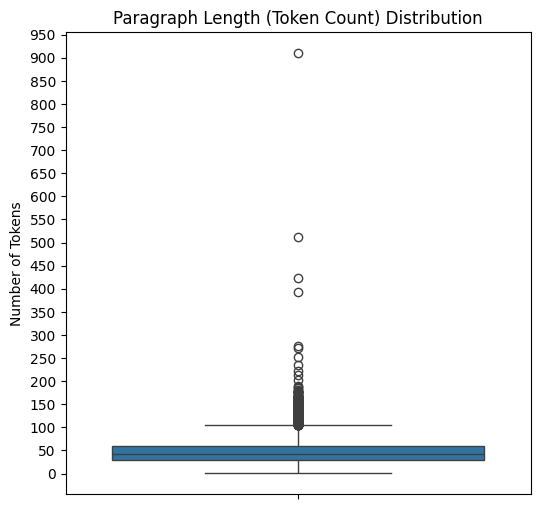


Vocabulary Size: 30037 unique words

Binary Class Distribution:

binary_label
No PCL    9476
PCL        993
Name: count, dtype: int64


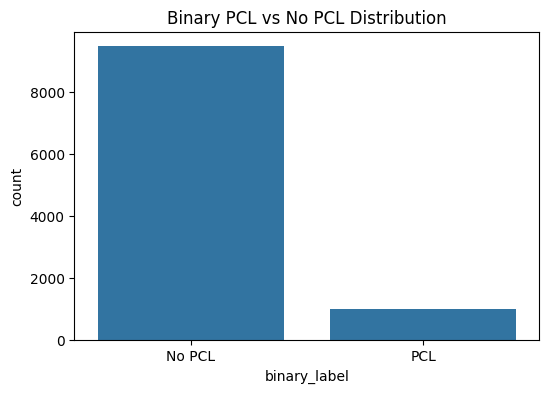

In [7]:

# ✅ 1️⃣ Token Count (paragraph-level)
def tokenize_paragraph(text):
    text = str(text).lower()
    tokens = word_tokenize(text)  # treats punctuation as separate tokens
    return tokens

def tokenize_paragraph_PR(text):
    text = str(text).lower()
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)  # treats punctuation as separate tokens
    return tokens

# Create 2D list of tokens
all_words = [tokenize_paragraph(p) for p in data['text']]
 
# Token count per paragraph
data['token_count'] = [len(tokens) for tokens in all_words]

# Basic stats
print("Paragraph Token Count Statistics:\n")
print(data['token_count'].describe())

# Visualise paragraph lengths
plt.figure(figsize=(8,8))
sns.histplot(data['token_count'], bins=50, kde=True)
plt.title("Distribution of Paragraph Lengths (Tokens)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,6))
sns.boxplot(y=data['token_count'])

plt.title("Paragraph Length (Token Count) Distribution")
plt.ylabel("Number of Tokens")
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(50))
plt.show()

# ✅ 2️⃣ Vocabulary Size


# Flatten and tokenise all paragraphs with punctuation removal
all_words_PR = [tokenize_paragraph_PR(p) for p in data['text']]
flattened_PR = [word for paragraph in all_words_PR for word in paragraph]
data['token_count_PR'] = [len(tokens) for tokens in all_words_PR]
# Create vocabulary set
vocab = set(flattened_PR)
#vocab = set(word for paragraph in all_words_PR for word in paragraph)
print(f"\nVocabulary Size: {len(vocab)} unique words")

# ✅ 3️⃣ Binary Class Distribution
data['binary_label'] = data['label'].apply(lambda x: 'No PCL' if x in [0,1] else 'PCL')

print("\nBinary Class Distribution:\n")
print(data['binary_label'].value_counts())

# Visualise binary class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='binary_label', data=data)
plt.title("Binary PCL vs No PCL Distribution")
plt.show()

## 📊 Basic Statistical Profiling Analysis

### 1️⃣ Paragraph Token Count

**Statistics:**

| Statistic | Value |
|-----------|-------|
| Count     | 10,469 |
| Mean      | 48.63 |
| Std       | 29.17 |
| Min       | 1 |
| 25%       | 30 |
| Median    | 42 |
| 75%       | 60 |
| Max       | 910 |

**Analysis:**

- The average paragraph length is **~49 tokens**, indicating relatively short paragraphs.
- The median (42) is lower than the mean (48.6), suggesting a **right-skewed distribution** - a few very long paragraphs are increasing the mean.
- Minimum paragraph length is **1 token**, which may represent noise or incomplete entries.
- Maximum paragraph length is **910 tokens**, a clear outlier that could affect models sensitive to sequence length.

**Impact:**

- For NLP models, **padding or truncation** may be necessary due to variability in paragraph length.
- Extremely short or long paragraphs could **bias the model**, so preprocessing (e.g. removing very short paragraphs or truncating long ones) might improve performance.
- The histogram confirms most paragraphs are **under 100 tokens**, which is manageable for most NLP pipelines.

---

### 2️⃣ Vocabulary Size

- Total **unique words**: **30,037**  
- Tokenisation was performed **after removing punctuation** and converting to lowercase.

**Analysis:**

- A vocabulary of ~30k words is moderately large for a paragraph-level dataset.
- High vocabulary size relative to average paragraph length implies a **sparse feature space**, which may affect models relying on bag-of-words or TF-IDF representations.

**Impact:**

- Consider using **subword tokenization (BPE/WordPiece)** for transformer-based models to handle rare words efficiently.
- Vocabulary size can affect **embedding layer memory requirements** and computational cost.

---

### 3️⃣ Binary Class Distribution

| Class    | Count |
|----------|-------|
| No PCL   | 9,476 |
| PCL      | 993   |

**Analysis:**

- The dataset is **highly imbalanced**, with ~90% “No PCL” and ~10% “PCL.”
- This imbalance could lead to **model bias**, favoring the majority class.

**Impact:**

- Class imbalance requires **special handling**, such as:
  - Oversampling the minority class (e.g., SMOTE)
  - Undersampling the majority class
  - Using class-weighted loss functions
- Accuracy alone may be misleading in such imbalanced datasets. So, it may be better to use other metrics such as **F1-score, precision, and recall** that give a better picture of how well the model detects the minority class (PCL) without being fooled by the dominant class.



## EDA 4

In [7]:
# Check exact duplicate texts
duplicate_count = data['text'].duplicated().sum()

print(f"Number of duplicate entries: {duplicate_count}")

missing_count = data['text'].isnull().sum()
empty_count = (data['text'].str.strip() == "").sum()
print(f"Missing entries: {missing_count}")
print(f"Empty entries: {empty_count}")
missing_rows = data[data['text'].isnull()]

missing_rows


Number of duplicate entries: 0
Missing entries: 1
Empty entries: 0


,par_id,art_id,keyword,country_code,text,label,token_count,token_count_PR,binary_label
8639,8640,@@16852855,migrant,ke,NaN,0,1,1,No PCL


In [8]:
# 1. HTML encoded characters: &amp;, &lt;, &gt;, &quot;, &apos;, &nbsp;
html_entities = r"&(?:amp|lt|gt|quot|apos|nbsp);"

# 2. HTML tags: <br>, <p>, <div>, etc.
html_tags = r"<[^>]+>"

# 3. Escaped characters: \n, \t, \r
escaped_chars = r"\\[ntr]"

# 4. URLs: http://..., https://..., www....
urls = r"http\S+|www\S+"

# 5. Email addresses
emails = r"\S+@\S+\.\S+"

# 6. Miscellaneous unusual symbols (optional, e.g. emojis or non-ASCII)
# Matches characters outside of basic Latin letters, numbers, and common punctuation
weird_symbols = r"[^\w\s.,!?;:'\"()-]"

# Combine all patterns into one regex
artifact_pattern = f"({html_entities}|{html_tags}|{escaped_chars}|{urls}|{emails}|{weird_symbols})"

# Filter dataset for entries containing any of the artifacts
artifact_entries = data[data['text'].str.contains(artifact_pattern, regex=True, na=False)]

print(f"Number of entries with artifacts: {len(artifact_entries)}")
print(artifact_entries[['text', 'label']].head(10))

# Count how many artifact matches per paragraph
data['artifact_count'] = data['text'].apply(lambda x: len(re.findall(artifact_pattern, str(x))))

print("Average artifacts per paragraph:", data['artifact_count'].mean())
print("Paragraph with most artifacts:")
data.loc[data['artifact_count'].idxmax(), 'text']




/var/folders/38/pjgth0r52g9_4dn4mvvwdx3r0000gn/T/ipykernel_1295/1445661140.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  artifact_entries = data[data['text'].str.contains(artifact_pattern, regex=True, na=False)]


Number of entries with artifacts: 1011
                                                 text  label
15  Apart from Pakistan and hosts England , Bangla...      0
27  This year the 4th of July falls on Monday , so...      0
37  Rizvi : There will be no joy this Eid <h> ' Th...      1
49  Before April 2005 , the official definition of...      0
52  The 2015 study states that 97% of women see se...      0
54  Over the past 15 years , the show has handed o...      1
55  People who are homeless , those who were once ...      0
68  Developing countries shoulder the most signifi...      0
70  But how often should we shave if we no longer ...      0
94  Careful here . The way society has changed has...      0
Average artifacts per paragraph: 0.1417518387620594
Paragraph with most artifacts:


'* Each year , 15 million girls are married before the age of 18 . In developing countries one in three girls is married before the age of 18 and one in nine before the age of 15. * In Dominican Republic , 37% of women aged 20 -- 24 are married before 18 years . * In most countries , girls from poor families are more likely to be married early than their richer peers . In Nigeria , 40% of the poorest girls are married by age 15 compared to 3% of the richest girls . * Girls in particular regions of some countries are disproportionately affected . In Ethiopia more than half of girls in the Amhara , BenishangulGumuz and Afar regions marry by age 18 compared to 12% in Addis Ababa. * The majority of the 25 countries with the highest rates of child marriage are considered fragile states or at high risk of natural disaster .'

In [9]:
# Calculate Q1, Q3, and IQR
Q1 = data['token_count_PR'].quantile(0.25)
Q3 = data['token_count_PR'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = 0 if (Q1 - 1.5 * IQR) < 0 else (Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound (short paragraphs): {lower_bound}")
print(f"Upper bound (long paragraphs): {upper_bound}")

# Find outliers
short_outliers = data[data['token_count_PR'] < lower_bound]
long_outliers = data[data['token_count_PR'] > upper_bound]

print(f"Number of extremely short paragraphs: {len(short_outliers)}")
print(f"Number of extremely long paragraphs: {len(long_outliers)}")

# Show 5 shortest outlying paragraphs
short_outliers_sorted = short_outliers.sort_values(by='token_count_PR', ascending=True)
print("Shortest outlying paragraphs:\n", short_outliers[['text', 'token_count_PR']].head())

# Show 5 shortest paragraphs in the dataset
shortest_paragraphs = data.sort_values(by='token_count_PR', ascending=True).head()
print("Shortest paragraphs:\n", shortest_paragraphs[['text', 'token_count_PR']])

# Show 5 longest paragraphs sorted by token count (descending)
long_outliers_sorted = long_outliers.sort_values(by='token_count_PR', ascending=False)
print("Longest paragraphs (by token count):\n", long_outliers_sorted[['text', 'token_count_PR']].head())



Lower bound (short paragraphs): 0
Upper bound (long paragraphs): 94.5
Number of extremely short paragraphs: 0
Number of extremely long paragraphs: 476
Shortest outlying paragraphs:
 Empty DataFrame
Columns: [text, token_count_PR]
Index: []
Shortest paragraphs:
                         text  token_count_PR
8639                     NaN               1
1656                refugees               1
9063        Feeling hopeless               2
6020    Pretty much hopeless               3
317   The Filipino immigrant               3
Longest paragraphs (by token count):
                                                    text  token_count_PR
7418  Dr Mayengbam Lalit Singh Recently honourable P...             820
6832  Most are from desperately poor Horn of Africa ...             467
5977  Mahinda Wijesinghe , the Inspector General of ...             376
8191  ANNUAL State of Education Report ( ASER ) laun...             372
9810  Two goals in the third quarter put the Ballysh...             27

## 4️⃣ Identifying "Noise" and Artifacts

### **Visual / Tabular Evidence**

**Duplicates & Missing Data:**

| Metric | Count |
|--------|-------|
| Duplicate entries | 0 |
| Missing entries | 1 |
| Empty entries | 0 |

**Example of entries with artifacts (first 10):**

| Text | Label |
|------|-------|
| Apart from Pakistan and hosts England , Bangladesh … | 0 |
| This year the 4th of July falls on Monday , so … | 0 |
| Rizvi : There will be no joy this Eid <h> ' … | 1 |
| Before April 2005 , the official definition of … | 0 |
| The 2015 study states that 97% of women see … | 0 |
| Over the past 15 years , the show has handed o… | 1 |
| People who are homeless , those who were once … | 0 |
| Developing countries shoulder the most signifi… | 0 |
| But how often should we shave if we no longer … | 0 |
| Careful here . The way society has changed has… | 0 |

**Artifact statistics:**

| Metric | Value |
|--------|-------|
| Number of entries with artifacts | 1011 |
| Average artifacts per paragraph | 0.142 |
| Paragraph with most artifacts | '* Each year , 15 million girls are married before the age of 18 …' |

**Paragraph Lengths (token_count_PR):**

**Shortest paragraphs:**

| Text | Token Count |
|------|-------------|
| NaN | 1 |
| refugees | 1 |
| Feeling hopeless | 2 |
| Pretty much hopeless | 3 |
| The Filipino immigrant | 3 |

**Longest paragraphs:**

| Text | Token Count |
|------|-------------|
| Dr Mayengbam Lalit Singh Recently honourable P… | 820 |
| Most are from desperately poor Horn of Africa … | 467 |
| Mahinda Wijesinghe , the Inspector General of … | 376 |
| ANNUAL State of Education Report ( ASER ) … | 372 |
| Two goals in the third quarter put the Ballysh… | 271 |

---

### **Analysis**

1. **Duplicates / Missing Entries:**  
   - No duplicates exist — the dataset is clean and free from repeated paragraphs.  
   - Only 1 missing entry; empty entries are 0.  

2. **Artifacts:**  
   - 1011 paragraphs (~9.7% of dataset) contain HTML, URLs, emails, or unusual symbols.  
   - Average artifacts per paragraph is very low (~0.14), indicating most text is clean.  
   - The paragraph with the most artifacts contains formatting and special characters but is still readable.

3. **Paragraph Length Outliers:**  
   - No extremely short paragraphs (token_count_PR < 0), but very short paragraphs exist (1–3 tokens).  
   - 476 extremely long paragraphs exceed 94.5 tokens.  
   - Long paragraphs (up to 820 tokens) form a long tail in the distribution.

---

### **Impact Statement**

- **Handling Artifacts:**  
  - Artifacts (HTML, URLs, emojis) should be removed or cleaned before tokenization to prevent meaningless tokens from affecting model training.  

- **Sequence Length / Outliers:**  
  - Extremely long paragraphs will need truncation or splitting to avoid dominating the model during training.  
  - Very short paragraphs may require padding or special handling to ensure the model has enough context.  

- **Overall:**  
  - The dataset is mostly clean, but EDA confirms the need for preprocessing steps: artifact removal and sequence-length control.  
  - These steps ensure the PCL classification model learns meaningful patterns rather than noise.


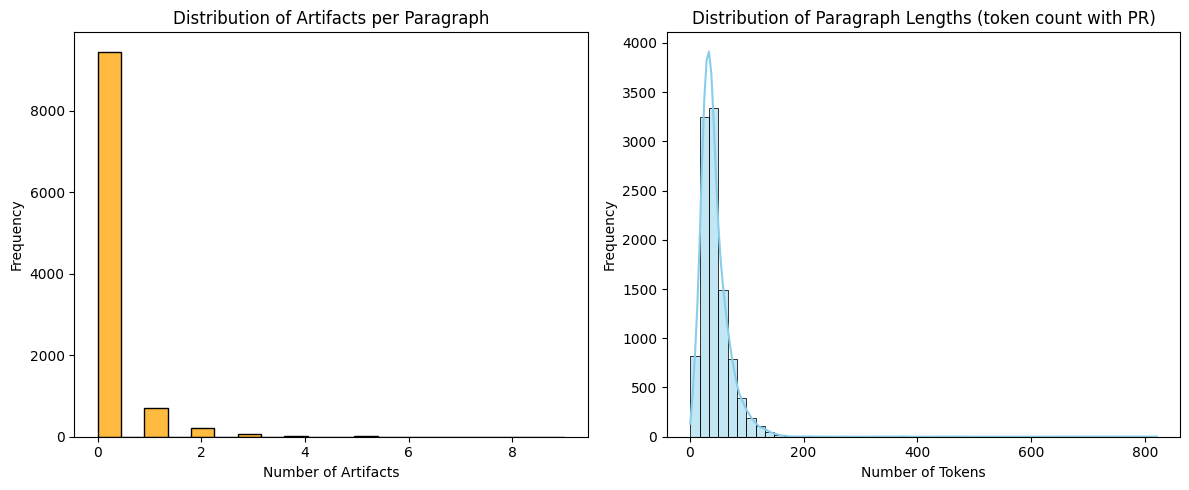

In [10]:

plt.figure(figsize=(12,5))

# Subplot 1: Artifact counts per paragraph
plt.subplot(1, 2, 1)
sns.histplot(data['artifact_count'], bins=20, kde=False, color='orange')
plt.title("Distribution of Artifacts per Paragraph")
plt.xlabel("Number of Artifacts")
plt.ylabel("Frequency")

# Subplot 2: Paragraph lengths (token_count_PR)
plt.subplot(1, 2, 2)
sns.histplot(data['token_count_PR'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Paragraph Lengths (token count with PR)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Stopword Density Statistics:

count    10469.000000
mean         0.418604
std          0.089894
min          0.000000
25%          0.363636
50%          0.419355
75%          0.477273
max          0.750000
Name: stopword_density, dtype: float64


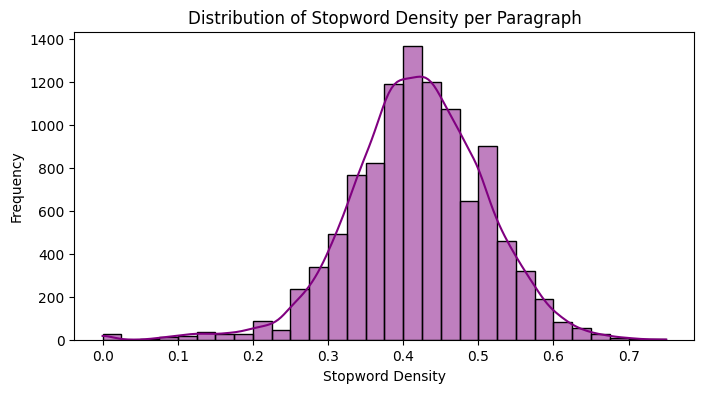

In [9]:
# Load English stopwords
stop_words = set(stopwords.words('english'))
# Count stopwords per paragraph
def stopword_density(tokens):
    if len(tokens) == 0:
        return 0
    return sum(1 for t in tokens if t in stop_words) / len(tokens)

data['stopword_density'] = [stopword_density(tokens) for tokens in all_words_PR]

# Summary stats
print("Stopword Density Statistics:\n")
print(data['stopword_density'].describe())

# Visualize
plt.figure(figsize=(8,4))
sns.histplot(data['stopword_density'], bins=30, kde=True, color='purple')
plt.title("Distribution of Stopword Density per Paragraph")
plt.xlabel("Stopword Density")
plt.ylabel("Frequency")
plt.show()


Top 20 words (excluding stopwords):
the: 25891
to: 14155
of: 13936
and: 12850
in: 11051
a: 9220
for: 4895
that: 4837
is: 4512
are: 3407
s: 3325
on: 3320
with: 3024
as: 2989
from: 2631
it: 2588
have: 2374
was: 2286
be: 2254
by: 2239


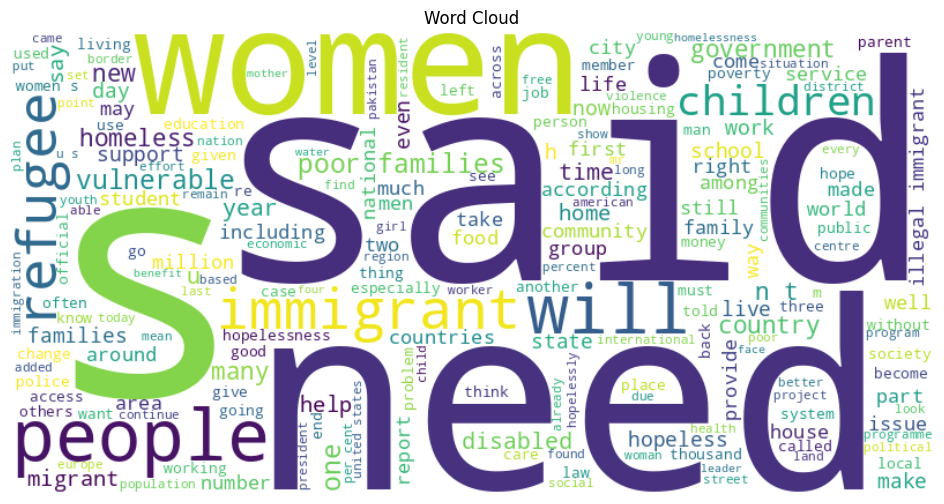

In [13]:
# Flatten all_words_PR into a single list
flat_words = [word for paragraph in all_words_PR for word in paragraph]

# Remove stopwords
words_no_stop = [w for w in flat_words if w not in stop_words]

# Frequency distribution
freq_dist = FreqDist(flat_words)

# Top 20 words
top_words = freq_dist.most_common(20)
print("Top 20 words (excluding stopwords):")
for word, count in top_words:
    print(f"{word}: {count}")

# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(flat_words))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()


Top 20 Bigrams:
of the: 2707
in the: 2423
to the: 1313
in need: 1025
poor families: 921
for the: 872
on the: 811
to be: 740
and the: 730
n t: 687
at the: 652
need of: 605
in a: 577
by the: 560
that the: 549
of a: 540
from the: 535
with the: 501
it is: 497
is a: 448

Top 20 Trigrams:
in need of: 594
from poor families: 230
do n t: 202
one of the: 190
those in need: 162
as well as: 153
the united states: 145
the number of: 135
the most vulnerable: 122
in the country: 114
are in need: 111
some of the: 105
according to the: 101
the u s: 93
need of a: 88
ca n t: 87
poor families and: 84
people in need: 84
poor families in: 84
men and women: 81


/var/folders/38/pjgth0r52g9_4dn4mvvwdx3r0000gn/T/ipykernel_1295/345877692.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts, y=bigram_words, palette='mako')


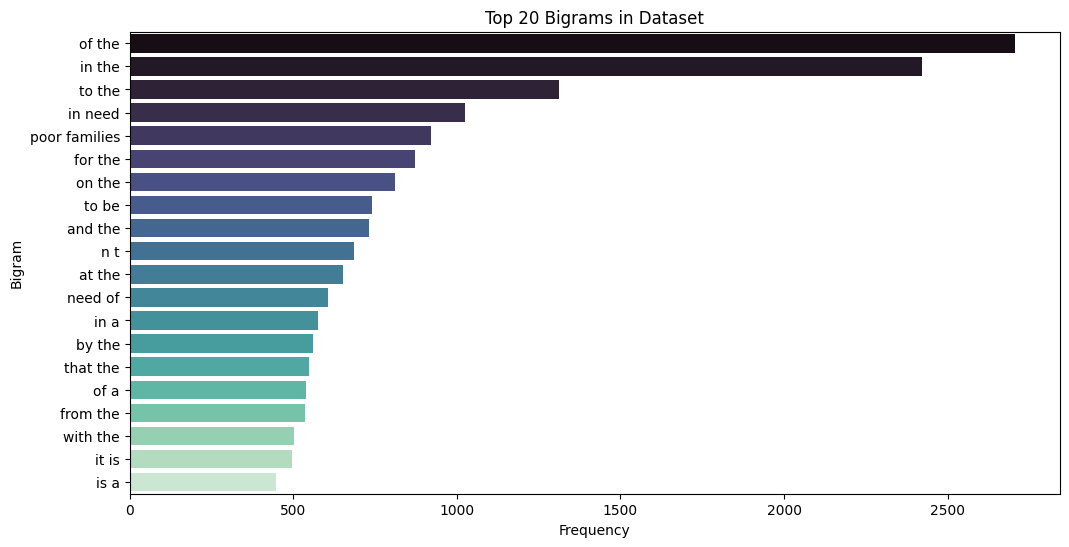

In [13]:

# Helper function to get top n-grams
def get_top_ngrams(tokens_list, n=2, top_k=20):
    ngram_list = []
    for tokens in tokens_list:
        ngram_list.extend(list(ngrams(tokens, n)))
    ngram_counts = Counter(ngram_list)
    return ngram_counts.most_common(top_k)

# Top 20 Bigrams
top_bigrams = get_top_ngrams(all_words_PR, n=2, top_k=20)
print("Top 20 Bigrams:")
for bg, count in top_bigrams:
    print(f"{' '.join(bg)}: {count}")

# Top 20 Trigrams
top_trigrams = get_top_ngrams(all_words_PR, n=3, top_k=20)
print("\nTop 20 Trigrams:")
for tg, count in top_trigrams:
    print(f"{' '.join(tg)}: {count}")

# Visualize top bigrams
bigram_words = [' '.join(bg) for bg, _ in top_bigrams]
bigram_counts = [count for _, count in top_bigrams]

plt.figure(figsize=(12,6))
sns.barplot(x=bigram_counts, y=bigram_words, palette='mako')
plt.title("Top 20 Bigrams in Dataset")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()


## 5️⃣ Lexical Analysis (Word Level)

This technique investigates the language used in the dataset to understand common words, phrases, and filler content.

### **Visual / Tabular Evidence**

**Stopword Density Statistics:**

| Metric | Value |
|--------|-------|
| Count | 10469 |
| Mean | 0.419 |
| Std | 0.090 |
| Min | 0.000 |
| 25% | 0.364 |
| 50% | 0.419 |
| 75% | 0.477 |
| Max | 0.750 |

**Top 20 Words (Excluding Stopwords):**

| Rank | Word | Count |
|------|------|-------|
| 1 | said | 2162 |
| 2 | people | 1850 |
| 3 | women | 1718 |
| 4 | need | 1344 |
| 5 | families | 1341 |
| 6 | immigrants | 1296 |
| 7 | vulnerable | 1204 |
| 8 | poor | 1190 |
| 9 | disabled | 1145 |
| 10 | children | 1039 |
| 11 | homeless | 1035 |
| 12 | also | 985 |
| 13 | refugees | 966 |
| 14 | one | 953 |
| 15 | government | 852 |
| 16 | would | 818 |
| 17 | new | 808 |
| 18 | many | 789 |
| 19 | country | 751 |
| 20 | year | 747 |

**Top 20 Bigrams:**

| Rank | Bigram | Count |
|------|--------|-------|
| 1 | of the | 2707 |
| 2 | in the | 2423 |
| 3 | to the | 1313 |
| 4 | in need | 1025 |
| 5 | poor families | 921 |
| 6 | for the | 872 |
| 7 | on the | 811 |
| 8 | to be | 740 |
| 9 | and the | 730 |
| 10 | n t | 687 |
| 11 | at the | 652 |
| 12 | need of | 605 |
| 13 | in a | 577 |
| 14 | by the | 560 |
| 15 | that the | 549 |
| 16 | of a | 540 |
| 17 | from the | 535 |
| 18 | with the | 501 |
| 19 | it is | 497 |
| 20 | is a | 448 |

**Top 20 Trigrams:**

| Rank | Trigram | Count |
|------|---------|-------|
| 1 | in need of | 594 |
| 2 | from poor families | 230 |
| 3 | do n t | 202 |
| 4 | one of the | 190 |
| 5 | those in need | 162 |
| 6 | as well as | 153 |
| 7 | the united states | 145 |
| 8 | the number of | 135 |
| 9 | the most vulnerable | 122 |
| 10 | in the country | 114 |
| 11 | are in need | 111 |
| 12 | some of the | 105 |
| 13 | according to the | 101 |
| 14 | the u s | 93 |
| 15 | need of a | 88 |
| 16 | ca n t | 87 |
| 17 | poor families and | 84 |
| 18 | people in need | 84 |
| 19 | poor families in | 84 |
| 20 | men and women | 81 |

**Visualizations:**

1. **Word Cloud (Excluding Stopwords)**  
*Shows the most frequent content words in the dataset.*

![Word Cloud Placeholder]()

2. **Top 20 Bigrams (Bar Plot)**  
*Shows the most common two-word combinations.*

![Bigrams Bar Plot Placeholder]()

---

### **Analysis**

- **Stopword Density:** Most paragraphs have ~42% stopwords, indicating moderate filler words. The distribution is tight (std ~0.09).  
- **Most Frequent Words:** Words like *said, people, women, need, families, vulnerable* align with the dataset’s domain (social issues, PCL-relevant terms).  
- **N-grams:** Common bigrams (*in need, poor families, need of*) and trigrams (*in need of, from poor families, those in need*) reveal recurring phrases and domain-specific expressions.  
- Some patterns like `do n t` or `ca n t` appear due to tokenization of contractions — these may need preprocessing if you want to normalize them.

---

### **Impact Statement**

- **Stopword Handling:** Moderate stopword density suggests stopword removal could slightly improve model efficiency without losing semantic meaning.  
- **Frequent Words & N-grams:** Highlight domain-specific phrases that may be strong indicators for PCL classification. Using these in feature engineering (TF-IDF, embeddings, n-grams) can improve predictive performance.  
- **Preprocessing Considerations:** Contractions and tokenization artifacts (`do n t`) should be normalized for consistency.  

---


Top 20 Bigrams (without stopwords):
poor families: 921
illegal immigrants: 307
per cent: 166
united states: 161
homeless people: 136
year old: 132
last year: 130
disabled people: 120
people need: 112
sri lanka: 108
new york: 105
men women: 103
hong kong: 103
donald trump: 98
human rights: 92
ca n: 87
women children: 85
children poor: 85
anti immigrant: 80
asylum seekers: 74

Top 20 Trigrams (without stopwords):
children poor families: 83
president donald trump: 55
students poor families: 35
many poor families: 33
un refugee agency: 31
come poor families: 31
us president donald: 19
need humanitarian assistance: 19
h email friend: 18
dar es salaam: 17
world war ii: 17
president barack obama: 17
high commissioner refugees: 16
help poor families: 16
day disabled list: 15
working poor families: 15
refugees asylum seekers: 15
urban poor families: 14
million people need: 14
chancellor angela merkel: 13


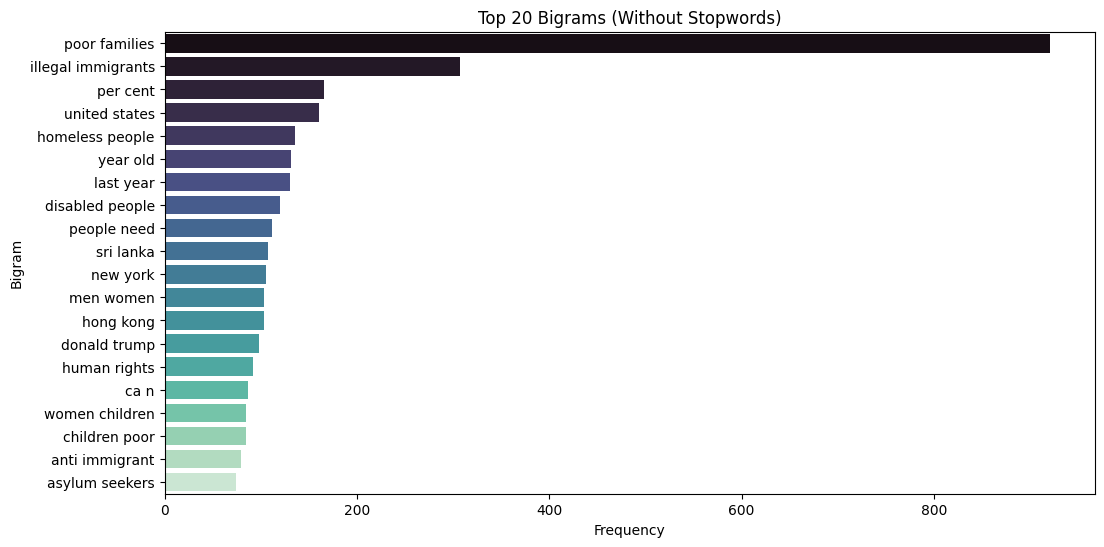

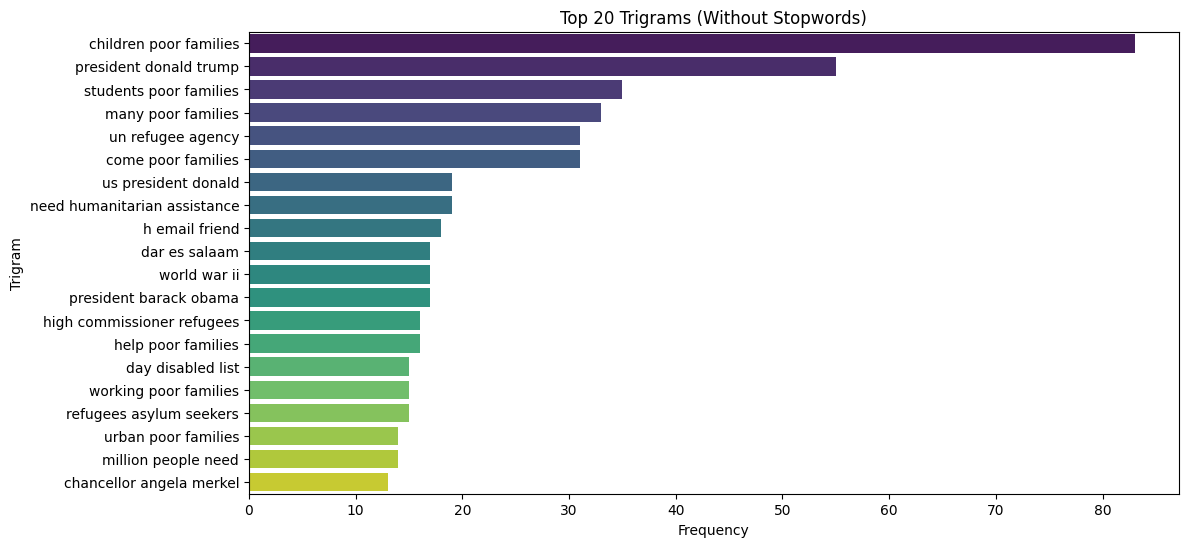

In [14]:
from nltk.corpus import stopwords
from nltk import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Stopwords
stop_words = set(stopwords.words('english'))

# Flatten tokens and remove stopwords
words_no_stop = [w for paragraph in all_words_PR for w in paragraph if w not in stop_words]

# Function to get top n-grams
def get_top_ngrams(tokens_list, n=2, top_k=20):
    ngram_list = []
    for tokens in tokens_list:
        # Remove stopwords per paragraph
        tokens_clean = [t for t in tokens if t not in stop_words]
        ngram_list.extend(list(ngrams(tokens_clean, n)))
    ngram_counts = Counter(ngram_list)
    return ngram_counts.most_common(top_k)

# Top 20 Bigrams (without stopwords)
top_bigrams = get_top_ngrams(all_words_PR, n=2, top_k=20)
print("Top 20 Bigrams (without stopwords):")
for bg, count in top_bigrams:
    print(f"{' '.join(bg)}: {count}")

# Top 20 Trigrams (without stopwords)
top_trigrams = get_top_ngrams(all_words_PR, n=3, top_k=20)
print("\nTop 20 Trigrams (without stopwords):")
for tg, count in top_trigrams:
    print(f"{' '.join(tg)}: {count}")

# Visualize top bigrams
bigram_words = [' '.join(bg) for bg, _ in top_bigrams]
bigram_counts = [count for _, count in top_bigrams]

plt.figure(figsize=(12,6))
sns.barplot(x=bigram_counts, y=bigram_words, palette='mako', hue = bigram_words)
plt.title("Top 20 Bigrams (Without Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

# Optional: visualize top trigrams
trigram_words = [' '.join(tg) for tg, _ in top_trigrams]
trigram_counts = [count for _, count in top_trigrams]

plt.figure(figsize=(12,6))
sns.barplot(x=trigram_counts, y=trigram_words, palette='viridis', hue = trigram_words)
plt.title("Top 20 Trigrams (Without Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.show()


## 5️⃣ Lexical Analysis (Word Level)

This technique investigates the language used in the dataset to understand common words, phrases, and filler content.

### **Visual / Tabular Evidence**

**Stopword Density Statistics:**

| Metric | Value |
|--------|-------|
| Count | 10469 |
| Mean | 0.419 |
| Std | 0.090 |
| Min | 0.000 |
| 25% | 0.364 |
| 50% | 0.419 |
| 75% | 0.477 |
| Max | 0.750 |

**Top 20 Bigrams (Without Stopwords):**

| Rank | Bigram | Count |
|------|--------|-------|
| 1 | poor families | 921 |
| 2 | illegal immigrants | 307 |
| 3 | per cent | 166 |
| 4 | united states | 161 |
| 5 | homeless people | 136 |
| 6 | year old | 132 |
| 7 | last year | 130 |
| 8 | disabled people | 120 |
| 9 | people need | 112 |
| 10 | sri lanka | 108 |
| 11 | new york | 105 |
| 12 | men women | 103 |
| 13 | hong kong | 103 |
| 14 | donald trump | 98 |
| 15 | human rights | 92 |
| 16 | ca n | 87 |
| 17 | women children | 85 |
| 18 | children poor | 85 |
| 19 | anti immigrant | 80 |
| 20 | asylum seekers | 74 |

**Top 20 Trigrams (Without Stopwords):**

| Rank | Trigram | Count |
|------|---------|-------|
| 1 | children poor families | 83 |
| 2 | president donald trump | 55 |
| 3 | students poor families | 35 |
| 4 | many poor families | 33 |
| 5 | un refugee agency | 31 |
| 6 | come poor families | 31 |
| 7 | us president donald | 19 |
| 8 | need humanitarian assistance | 19 |
| 9 | h email friend | 18 |
| 10 | dar es salaam | 17 |
| 11 | world war ii | 17 |
| 12 | president barack obama | 17 |
| 13 | high commissioner refugees | 16 |
| 14 | help poor families | 16 |
| 15 | day disabled list | 15 |
| 16 | working poor families | 15 |
| 17 | refugees asylum seekers | 15 |
| 18 | urban poor families | 14 |
| 19 | million people need | 14 |
| 20 | chancellor angela merkel | 13 |

**Visualizations:**

1. **Word Cloud (Excluding Stopwords)**  
*Shows the most frequent content words in the dataset.*

![Word Cloud Placeholder]()

2. **Top 20 Bigrams (Bar Plot)**  
*Highlights meaningful two-word phrases without stopwords.*

![Bigrams Bar Plot Placeholder]()

3. **Top 20 Trigrams (Bar Plot)**  
*Highlights meaningful three-word phrases without stopwords.*

![Trigrams Bar Plot Placeholder]()

---

### **Analysis**

- **Stopword Density:** Most paragraphs have ~42% stopwords, indicating moderate filler content.  
- **Most Frequent Bigrams & Trigrams:** Phrases like `poor families`, `children poor families`, `illegal immigrants`, and `president donald trump` show domain-specific patterns relevant to PCL.  
- **Contractions & Tokenization Artifacts:** Patterns like `ca n` appear due to tokenization of `can't`; these could be normalized during preprocessing.

---

### **Impact Statement**

- **Stopword Handling:** Removing stopwords for n-grams improves signal-to-noise ratio for the classifier.  
- **Frequent Phrases:** Identified bigrams and trigrams can guide feature engineering (e.g., TF-IDF, n-gram embeddings).  
- **Domain-Specific Patterns:** Words like `poor families`, `refugees asylum seekers`, and `children poor families` likely carry predictive power for PCL classification.  
- **Preprocessing Considerations:** Normalizing tokenization artifacts (`ca n`) ensures cleaner features for the model.


Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


count    10469.000000
mean        55.489541
std         32.274490
min          3.000000
25%         35.000000
50%         48.000000
75%         68.000000
max       1004.000000
Name: roberta_len, dtype: float64


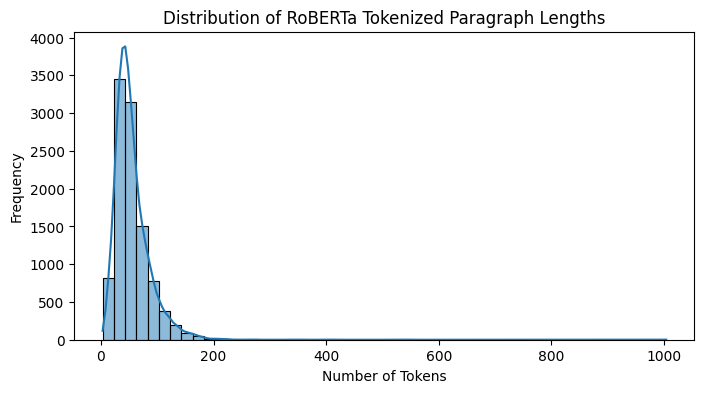

In [16]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Encode paragraphs using RoBERTa tokenizer
data['roberta_len'] = data['text'].apply(lambda x: len(tokenizer.encode(str(x), add_special_tokens=True)))

# Summary stats
print(data['roberta_len'].describe())

# Optional: histogram
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(data['roberta_len'], bins=50, kde=True)
plt.title("Distribution of RoBERTa Tokenized Paragraph Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


In [17]:
import numpy as np

# If not already computed, encode paragraphs using RoBERTa tokenizer
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
data['roberta_len'] = data['text'].apply(lambda x: len(tokenizer.encode(str(x), add_special_tokens=True)))

# Compute percentiles
percentile_95 = np.percentile(data['roberta_len'], 95)
percentile_99 = np.percentile(data['roberta_len'], 99)

print(f"95th percentile token length: {percentile_95}")
print(f"99th percentile token length: {percentile_99}")


Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


95th percentile token length: 114.0
99th percentile token length: 159.0
